# NB6: Feature Selection & Modeling (206-row dataset)

**Goal:** Find the optimal feature subset from nb5's ~73 descriptors, then train
regression + classification models on 206 rows.

**Approach:**
1. Clean: remove constant/NaN columns
2. Exhaustive search: all singles (~60), all pairs (~1800), all triples (~35k)
3. Forward selection: extend best triples to 4-8 features
4. SHAP analysis on winning models
5. Final regression (LOO R2) + classification (LOO F1) with best features

**Location:** `Keshav-DDP/k-path/nb6_feature_selection.ipynb`

## Cell 1: Configuration -- ALL PATHS HERE

**IMPORTANT:** If you move this notebook, update these paths.
This notebook lives in: `Keshav-DDP/k-path/`

In [17]:
import os

# =============================================================================
# PATHS -- CHANGE THESE IF YOU MOVE THE NOTEBOOK
# =============================================================================

# Input: the unified 206-row CSV from nb5
# Contains all descriptors + identifiers + Rashba_parameter target
INPUT_CSV = os.path.join(".", "nb5_kpath_descriptors-results", "rashba_206_all_descriptors.csv")

# Output: all results go here
RESULTS_DIR = os.path.join(".", "nb6_feature_selection-results")

# =============================================================================
# Verify and create dirs
# =============================================================================
print("=" * 65)
print("  PATH CONFIGURATION")
print("=" * 65)
for name, path in [("INPUT_CSV", INPUT_CSV), ("RESULTS_DIR", RESULTS_DIR)]:
    exists = os.path.exists(path)
    status = "OK" if exists else ("will create" if "results" in name.lower() else "MISSING")
    print(f"  [{status:12s}] {name:15s} = {path}")

os.makedirs(RESULTS_DIR, exist_ok=True)
print(f"\n  All outputs -> {RESULTS_DIR}/")

  PATH CONFIGURATION
  [OK          ] INPUT_CSV       = .\nb5_kpath_descriptors-results\rashba_206_all_descriptors.csv
  [OK          ] RESULTS_DIR     = .\nb6_feature_selection-results

  All outputs -> .\nb6_feature_selection-results/


## Cell 2: Imports

In [18]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
from itertools import combinations
from time import time

from sklearn.model_selection import (
    KFold, LeaveOneOut, StratifiedKFold, cross_val_score,
    cross_val_predict, GridSearchCV
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    r2_score, mean_squared_error, mean_absolute_error,
    f1_score, roc_auc_score, accuracy_score, precision_score,
    recall_score, classification_report
)
from xgboost import XGBRegressor, XGBClassifier

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams.update({'font.size': 11})

print("Imports OK.")

Imports OK.


## Cell 3: Load and clean data

In [19]:
df = pd.read_csv(INPUT_CSV)
print(f"Loaded: {df.shape[0]} rows, {df.shape[1]} columns")

# Identifiers and target
ID_COLS = ['Formula', 'uid', 'kpath']
TARGET = 'Rashba_parameter'

# All potential feature columns
all_feature_cols = [c for c in df.columns if c not in ID_COLS + [TARGET]]
print(f"Potential features: {len(all_feature_cols)}")

# --- Clean: remove constant, near-constant, and high-NaN columns ---
remove_cols = set()

for col in all_feature_cols:
    if df[col].isna().mean() > 0.5:
        remove_cols.add(col)
        continue
    if df[col].dropna().nunique() <= 1:
        remove_cols.add(col)

print(f"\nRemoving {len(remove_cols)} columns (constant or >50% NaN):")
for col in sorted(remove_cols):
    reason = "NaN" if df[col].isna().mean() > 0.5 else "constant"
    print(f"  {col:45s} ({reason})")

feature_cols = sorted([c for c in all_feature_cols if c not in remove_cols])
print(f"\nUsable features: {len(feature_cols)}")

# Prepare X and y
X_full = df[feature_cols].fillna(0).values
y = df[TARGET].values
feature_names = np.array(feature_cols)

print(f"X shape: {X_full.shape}, y shape: {y.shape}")
print(f"y range: [{y.min():.3f}, {y.max():.3f}], mean={y.mean():.3f}")

Loaded: 205 rows, 134 columns
Potential features: 130

Removing 7 columns (constant or >50% NaN):
  ppoint_n_atoms                                (constant)
  ppoint_plane_heavy_frac                       (constant)
  ppoint_plane_max_Z                            (constant)
  ppoint_plane_max_mass                         (constant)
  ppoint_plane_mean_Z                           (constant)
  ppoint_plane_mean_mass                        (constant)
  ppoint_plane_sum_Z4                           (constant)

Usable features: 123
X shape: (205, 123), y shape: (205,)
y range: [0.393, 4.804], mean=1.604


## Cell 4: Helper -- fast XGBoost evaluation

In [20]:
XGB_PARAMS = dict(
    n_estimators=100, max_depth=3, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    reg_alpha=1.0, reg_lambda=1.0,
    random_state=42, verbosity=0
)


def quick_r2(feature_indices, X, y, cv_splits=5):
    """Quick 5-fold CV R2 for a set of feature indices."""
    X_sub = X[:, feature_indices]
    model = XGBRegressor(**XGB_PARAMS)
    scores = cross_val_score(model, X_sub, y, cv=cv_splits, scoring='r2', n_jobs=1)
    return np.mean(scores)


def loo_r2(feature_indices, X, y):
    """Leave-One-Out R2 for a set of feature indices."""
    X_sub = X[:, feature_indices]
    model = XGBRegressor(**XGB_PARAMS)
    y_pred = cross_val_predict(model, X_sub, y, cv=LeaveOneOut())
    return r2_score(y, y_pred)


# Quick test
test_r2 = quick_r2([0, 1, 2], X_full, y)
print(f"Test (first 3 features): 5-fold R2 = {test_r2:.4f}")

Test (first 3 features): 5-fold R2 = 0.2109


## Cell 5: Phase 1 -- Exhaustive singles

Test every single feature individually.

In [21]:
print("=" * 65)
print("  PHASE 1: EXHAUSTIVE SINGLES")
print("=" * 65)

t0 = time()
single_results = []

for i, fname in enumerate(feature_names):
    r2 = quick_r2([i], X_full, y)
    single_results.append({'features': fname, 'indices': (i,), 'n_feat': 1, 'cv5_r2': r2})

single_df = pd.DataFrame(single_results).sort_values('cv5_r2', ascending=False).reset_index(drop=True)
print(f"Done in {time()-t0:.1f}s. Top 20 single features:")
print(single_df[['features', 'cv5_r2']].head(20).to_string(index=False))

single_df.to_csv(os.path.join(RESULTS_DIR, "phase1_singles.csv"), index=False)

  PHASE 1: EXHAUSTIVE SINGLES
Done in 10.3s. Top 20 single features:
              features    cv5_r2
    pmid_grdf_trig_max  0.080641
    pend_grdf_trig_max  0.025945
            kend_degen -0.055962
      E_pfrac_relevant -0.063117
       kpath_angle_deg -0.074385
           kend_frac_y -0.075028
  pline_grdf_gauss_max -0.078041
pline_plane_heavy_frac -0.079222
   pline_grdf_trig_max -0.085334
           kmid_frac_x -0.085372
                kvec_z -0.088803
  pline_grdf_gauss_std -0.089119
  pline_grdf_trig_mean -0.089406
pline_n_atoms_on_plane -0.089543
 pline_grdf_bessel_std -0.091160
           kend_frac_x -0.091718
   pend_grdf_trig_mean -0.094393
       kinterior_degen -0.101157
           kmid_frac_y -0.102362
  pline_plane_max_mass -0.103515


## Cell 6: Phase 2 -- Exhaustive pairs

In [22]:
print("=" * 65)
print("  PHASE 2: EXHAUSTIVE PAIRS")
print("=" * 65)

n_feat = len(feature_names)
n_pairs = n_feat * (n_feat - 1) // 2
print(f"Testing {n_pairs} pairs...")

t0 = time()
pair_results = []
best_pair_r2 = -999

for count, (i, j) in enumerate(combinations(range(n_feat), 2)):
    r2 = quick_r2([i, j], X_full, y)
    pair_results.append({
        'features': f"{feature_names[i]} + {feature_names[j]}",
        'feat_list': f"{feature_names[i]},{feature_names[j]}",
        'indices': (i, j),
        'n_feat': 2,
        'cv5_r2': r2
    })
    if r2 > best_pair_r2:
        best_pair_r2 = r2
    if (count + 1) % 500 == 0:
        elapsed = time() - t0
        rate = (count + 1) / elapsed
        remaining = (n_pairs - count - 1) / rate
        print(f"  {count+1}/{n_pairs} ({elapsed:.0f}s elapsed, ~{remaining:.0f}s left, best={best_pair_r2:.4f})")

pair_df = pd.DataFrame(pair_results).sort_values('cv5_r2', ascending=False).reset_index(drop=True)
print(f"\nDone in {time()-t0:.1f}s. Top 20 pairs:")
print(pair_df[['features', 'cv5_r2']].head(20).to_string(index=False))

pair_df.to_csv(os.path.join(RESULTS_DIR, "phase2_pairs.csv"), index=False)

  PHASE 2: EXHAUSTIVE PAIRS
Testing 7503 pairs...
  500/7503 (57s elapsed, ~803s left, best=0.2568)
  1000/7503 (112s elapsed, ~731s left, best=0.2568)
  1500/7503 (166s elapsed, ~666s left, best=0.2568)
  2000/7503 (222s elapsed, ~611s left, best=0.2568)
  2500/7503 (278s elapsed, ~556s left, best=0.2568)
  3000/7503 (334s elapsed, ~501s left, best=0.2568)
  3500/7503 (391s elapsed, ~447s left, best=0.2568)
  4000/7503 (450s elapsed, ~394s left, best=0.2568)
  4500/7503 (508s elapsed, ~339s left, best=0.2568)
  5000/7503 (566s elapsed, ~283s left, best=0.2568)
  5500/7503 (623s elapsed, ~227s left, best=0.2568)
  6000/7503 (678s elapsed, ~170s left, best=0.2568)
  6500/7503 (736s elapsed, ~114s left, best=0.2568)
  7000/7503 (793s elapsed, ~57s left, best=0.2568)
  7500/7503 (851s elapsed, ~0s left, best=0.2568)

Done in 851.2s. Top 20 pairs:
                                    features   cv5_r2
       E_pfrac_relevant + pmid_grdf_trig_max 0.256788
       E_pfrac_relevant + pend_grdf_

## Cell 7: Phase 3 -- Exhaustive triples

This may take 30-60 min. Set `SKIP_TRIPLES = True` to skip.

In [23]:
SKIP_TRIPLES = False  # Set True if too slow

if not SKIP_TRIPLES:
    print("=" * 65)
    print("  PHASE 3: EXHAUSTIVE TRIPLES")
    print("=" * 65)

    n_triples = n_feat * (n_feat - 1) * (n_feat - 2) // 6
    print(f"Testing {n_triples} triples...")

    t0 = time()
    triple_results = []
    best_triple_r2 = -999

    for count, (i, j, k) in enumerate(combinations(range(n_feat), 3)):
        r2 = quick_r2([i, j, k], X_full, y)
        triple_results.append({
            'features': f"{feature_names[i]} + {feature_names[j]} + {feature_names[k]}",
            'feat_list': f"{feature_names[i]},{feature_names[j]},{feature_names[k]}",
            'indices': (i, j, k),
            'n_feat': 3,
            'cv5_r2': r2
        })
        if r2 > best_triple_r2:
            best_triple_r2 = r2
        if (count + 1) % 5000 == 0:
            elapsed = time() - t0
            rate = (count + 1) / elapsed
            remaining = (n_triples - count - 1) / rate
            print(f"  {count+1}/{n_triples} ({elapsed:.0f}s, ~{remaining/60:.1f}min left, best={best_triple_r2:.4f})")

    triple_df = pd.DataFrame(triple_results).sort_values('cv5_r2', ascending=False).reset_index(drop=True)
    print(f"\nDone in {(time()-t0)/60:.1f} min. Top 20 triples:")
    print(triple_df[['features', 'cv5_r2']].head(20).to_string(index=False))

    triple_df.to_csv(os.path.join(RESULTS_DIR, "phase3_triples.csv"), index=False)
else:
    print("SKIPPED exhaustive triples. Forward selection will still find good sets.")
    triple_df = None

  PHASE 3: EXHAUSTIVE TRIPLES
Testing 302621 triples...
  5000/302621 (612s, ~606.8min left, best=0.3483)
  10000/302621 (1197s, ~583.7min left, best=0.3483)
  15000/302621 (1710s, ~546.4min left, best=0.3483)
  20000/302621 (2224s, ~523.7min left, best=0.4180)
  25000/302621 (2795s, ~517.3min left, best=0.4185)
  30000/302621 (3285s, ~497.6min left, best=0.4185)
  35000/302621 (3770s, ~480.5min left, best=0.4185)
  40000/302621 (4249s, ~464.9min left, best=0.4185)
  45000/302621 (4735s, ~451.8min left, best=0.4185)
  50000/302621 (5225s, ~440.0min left, best=0.4185)
  55000/302621 (5716s, ~428.9min left, best=0.4185)
  60000/302621 (6197s, ~417.7min left, best=0.4185)
  65000/302621 (6679s, ~407.0min left, best=0.4185)
  70000/302621 (7190s, ~398.2min left, best=0.4185)
  75000/302621 (7779s, ~393.5min left, best=0.4185)
  80000/302621 (8275s, ~383.8min left, best=0.4185)
  85000/302621 (8761s, ~373.8min left, best=0.4185)
  90000/302621 (9247s, ~364.1min left, best=0.4185)
  95000/30

## Cell 8: Phase 4 -- Forward selection (extend to 4-8 features)

Starting from top triples (or pairs if triples skipped), greedily add
the feature that improves R2 the most.

In [24]:
print("=" * 65)
print("  PHASE 4: FORWARD SELECTION (4-8 features)")
print("=" * 65)


def forward_select(starting_indices, X, y, feature_names, max_features=8):
    """Greedy forward feature selection from a starting set."""
    current = list(starting_indices)
    all_indices = set(range(len(feature_names)))
    history = [{
        'n_feat': len(current),
        'features': [feature_names[i] for i in current],
        'cv5_r2': quick_r2(current, X, y),
    }]

    while len(current) < max_features:
        remaining = all_indices - set(current)
        if not remaining:
            break

        best_r2 = -999
        best_idx = None

        for idx in remaining:
            r2 = quick_r2(current + [idx], X, y)
            if r2 > best_r2:
                best_r2 = r2
                best_idx = idx

        current.append(best_idx)
        history.append({
            'n_feat': len(current),
            'features': [feature_names[i] for i in current],
            'cv5_r2': best_r2,
        })

        # Stop if getting worse
        if best_r2 < history[-2]['cv5_r2'] - 0.02:
            break

    return history, current


# --- A) Forward select from top triples ---
fwd_results = []
source_df = triple_df if (triple_df is not None and len(triple_df) > 0) else pair_df
source_name = "triple" if triple_df is not None else "pair"

print(f"\nA) Extending top 5 {source_name}s:")
for rank in range(min(5, len(source_df))):
    row = source_df.iloc[rank]
    starting = list(row['indices'])
    print(f"\n  Rank {rank+1}: {row['features']} (R2={row['cv5_r2']:.4f})")

    history, final = forward_select(starting, X_full, y, feature_names)
    for h in history:
        h['source'] = f"{source_name}_rank{rank+1}"
        fwd_results.append(h)
        print(f"    {h['n_feat']} feat: R2={h['cv5_r2']:.4f} -> {', '.join(h['features'])}")

# --- B) Forward select from scratch ---
print("\n\nB) Forward selection from scratch (starting from best single):")
best_single_idx = single_df.iloc[0]['indices'][0]
history_scratch, _ = forward_select([best_single_idx], X_full, y, feature_names)
for h in history_scratch:
    h['source'] = 'from_scratch'
    fwd_results.append(h)
    print(f"  {h['n_feat']} feat: R2={h['cv5_r2']:.4f} -> {', '.join(h['features'])}")

fwd_df = pd.DataFrame(fwd_results)
fwd_df.to_csv(os.path.join(RESULTS_DIR, "phase4_forward_selection.csv"), index=False)

  PHASE 4: FORWARD SELECTION (4-8 features)

A) Extending top 5 triples:

  Rank 1: E_pfrac_relevant + pmid_grdf_trig_max + pstart_afs_gauss_std (R2=0.4185)
    3 feat: R2=0.4185 -> E_pfrac_relevant, pmid_grdf_trig_max, pstart_afs_gauss_std
    4 feat: R2=0.3975 -> E_pfrac_relevant, pmid_grdf_trig_max, pstart_afs_gauss_std, kvec_z

  Rank 2: E_pfrac_relevant + ehull + pmid_afs_gauss_std (R2=0.4180)
    3 feat: R2=0.4180 -> E_pfrac_relevant, ehull, pmid_afs_gauss_std
    4 feat: R2=0.4771 -> E_pfrac_relevant, ehull, pmid_afs_gauss_std, kpath_angle_deg
    5 feat: R2=0.4860 -> E_pfrac_relevant, ehull, pmid_afs_gauss_std, kpath_angle_deg, kstart_frac_y
    6 feat: R2=0.4637 -> E_pfrac_relevant, ehull, pmid_afs_gauss_std, kpath_angle_deg, kstart_frac_y, band_binary

  Rank 3: E_pfrac_relevant + pend_grdf_trig_max + pstart_afs_gauss_std (R2=0.3955)
    3 feat: R2=0.3955 -> E_pfrac_relevant, pend_grdf_trig_max, pstart_afs_gauss_std
    4 feat: R2=0.3784 -> E_pfrac_relevant, pend_grdf_trig_ma

## Cell 9: Consolidate -- best feature sets by size

In [25]:
print("=" * 65)
print("  BEST FEATURE SETS BY SIZE (5-fold CV R2)")
print("=" * 65)

# Collect everything into one table
all_combos = []

for _, row in single_df.iterrows():
    all_combos.append({'n_feat': 1, 'features': row['features'], 'cv5_r2': row['cv5_r2']})

for _, row in pair_df.head(100).iterrows():
    all_combos.append({'n_feat': 2, 'features': row['features'], 'cv5_r2': row['cv5_r2']})

if triple_df is not None:
    for _, row in triple_df.head(100).iterrows():
        all_combos.append({'n_feat': 3, 'features': row['features'], 'cv5_r2': row['cv5_r2']})

for _, row in fwd_df.iterrows():
    feat_str = ', '.join(row['features']) if isinstance(row['features'], list) else str(row['features'])
    all_combos.append({'n_feat': row['n_feat'], 'features': feat_str, 'cv5_r2': row['cv5_r2']})

combo_df = pd.DataFrame(all_combos)

print("\nBest 5-fold CV R2 at each feature count:\n")
for n in sorted(combo_df['n_feat'].unique()):
    subset = combo_df[combo_df['n_feat'] == n].sort_values('cv5_r2', ascending=False)
    best = subset.iloc[0]
    print(f"  {int(n)} features: R2 = {best['cv5_r2']:.4f}")
    print(f"    {best['features']}\n")

  BEST FEATURE SETS BY SIZE (5-fold CV R2)

Best 5-fold CV R2 at each feature count:

  1 features: R2 = 0.0806
    pmid_grdf_trig_max

  2 features: R2 = 0.2568
    E_pfrac_relevant + pmid_grdf_trig_max

  3 features: R2 = 0.4185
    E_pfrac_relevant + pmid_grdf_trig_max + pstart_afs_gauss_std

  4 features: R2 = 0.4771
    E_pfrac_relevant, ehull, pmid_afs_gauss_std, kpath_angle_deg

  5 features: R2 = 0.4860
    E_pfrac_relevant, ehull, pmid_afs_gauss_std, kpath_angle_deg, kstart_frac_y

  6 features: R2 = 0.4637
    E_pfrac_relevant, ehull, pmid_afs_gauss_std, kpath_angle_deg, kstart_frac_y, band_binary

  7 features: R2 = 0.4207
    E_pfrac_relevant, pmid_grdf_trig_max, pstart_grdf_gauss_mean, kend_frac_x, kvec_z, pstart_afs_bessel_std, pend_afs_gauss_mean

  8 features: R2 = 0.4343
    E_pfrac_relevant, ehull, pstart_afs_gauss_std, pmid_afs_gauss_std, kpath_angle_deg, pstart_afs_bessel_std, sum_Z4, pmid_grdf_trig_max



## Cell 10: LOO R2 on top candidates

5-fold is fast but LOO is the gold standard. Test top 3 at each feature count.

In [26]:
print("=" * 65)
print("  LOO R2 FOR TOP CANDIDATES")
print("=" * 65)

# Gather top 3 at each feature count
loo_candidates = []
for n in sorted(combo_df['n_feat'].unique()):
    subset = combo_df[combo_df['n_feat'] == n].sort_values('cv5_r2', ascending=False)
    for _, row in subset.head(3).iterrows():
        loo_candidates.append(row)

print(f"Evaluating {len(loo_candidates)} candidates with LOO...\n")

loo_results = []
for count, cand in enumerate(loo_candidates):
    feat_str = cand['features']
    # Parse feature names (handle both '+' and ',' separators)
    if '+' in feat_str:
        feats = [f.strip() for f in feat_str.split('+')]
    elif ',' in feat_str:
        feats = [f.strip() for f in feat_str.split(',')]
    else:
        feats = [feat_str.strip()]

    # Map to indices
    feat_indices = []
    for f in feats:
        matches = np.where(feature_names == f)[0]
        if len(matches) > 0:
            feat_indices.append(matches[0])

    if not feat_indices:
        continue

    X_sub = X_full[:, feat_indices]
    model = XGBRegressor(**XGB_PARAMS)
    y_pred = cross_val_predict(model, X_sub, y, cv=LeaveOneOut())
    loo_r2_val = r2_score(y, y_pred)
    loo_mae = mean_absolute_error(y, y_pred)

    loo_results.append({
        'n_feat': len(feat_indices),
        'features': ' + '.join(feats),
        'cv5_r2': cand['cv5_r2'],
        'loo_r2': loo_r2_val,
        'loo_mae': loo_mae,
    })
    print(f"  [{count+1}/{len(loo_candidates)}] {len(feat_indices)} feat, "
          f"CV5={cand['cv5_r2']:.4f}, LOO={loo_r2_val:.4f}: {' + '.join(feats)}")

loo_df = pd.DataFrame(loo_results).sort_values('loo_r2', ascending=False).reset_index(drop=True)
loo_df.to_csv(os.path.join(RESULTS_DIR, "phase5_loo_results.csv"), index=False)

print(f"\n{'='*65}")
print("  TOP 10 BY LOO R2")
print(f"{'='*65}")
print(loo_df[['n_feat', 'features', 'cv5_r2', 'loo_r2', 'loo_mae']].head(10).to_string(index=False))

  LOO R2 FOR TOP CANDIDATES
Evaluating 24 candidates with LOO...

  [1/24] 1 feat, CV5=0.0806, LOO=0.2878: pmid_grdf_trig_max
  [2/24] 1 feat, CV5=0.0806, LOO=0.2878: pmid_grdf_trig_max
  [3/24] 1 feat, CV5=0.0259, LOO=0.2677: pend_grdf_trig_max
  [4/24] 2 feat, CV5=0.2568, LOO=0.4150: E_pfrac_relevant + pmid_grdf_trig_max
  [5/24] 2 feat, CV5=0.2529, LOO=0.4158: pmid_grdf_trig_max + E_pfrac_relevant
  [6/24] 2 feat, CV5=0.2115, LOO=0.4065: E_pfrac_relevant + pend_grdf_trig_max
  [7/24] 3 feat, CV5=0.4185, LOO=0.4883: E_pfrac_relevant + pmid_grdf_trig_max + pstart_afs_gauss_std
  [8/24] 3 feat, CV5=0.4185, LOO=0.4883: E_pfrac_relevant + pmid_grdf_trig_max + pstart_afs_gauss_std
  [9/24] 3 feat, CV5=0.4180, LOO=0.5302: E_pfrac_relevant + ehull + pmid_afs_gauss_std
  [10/24] 4 feat, CV5=0.4771, LOO=0.5579: E_pfrac_relevant + ehull + pmid_afs_gauss_std + kpath_angle_deg
  [11/24] 4 feat, CV5=0.4046, LOO=0.5166: pmid_grdf_trig_max + E_pfrac_relevant + E_pfrac_CBM + radius_mean
  [12/24] 4 

## Cell 11: SHAP analysis on the best model

  SHAP / FEATURE IMPORTANCE
SHAP not installed (pip install shap). Using XGBoost importance instead.

           feature  importance
pmid_afs_gauss_std    0.339834
  E_pfrac_relevant    0.285894
             ehull    0.275956
   kpath_angle_deg    0.098316


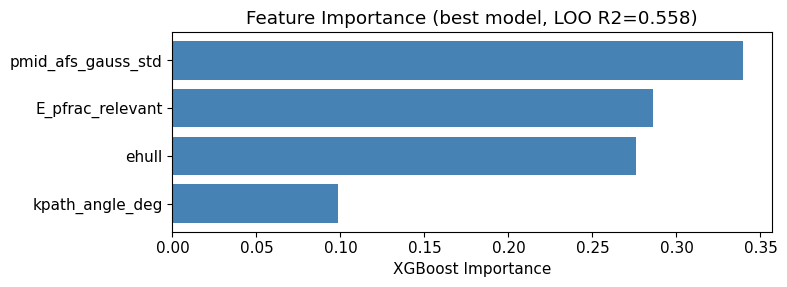

In [27]:
print("=" * 65)
print("  SHAP / FEATURE IMPORTANCE")
print("=" * 65)

best_loo = loo_df.iloc[0]
feats = [f.strip() for f in best_loo['features'].split('+')]
feat_indices = [np.where(feature_names == f)[0][0] for f in feats]
X_best = X_full[:, feat_indices]

model = XGBRegressor(**XGB_PARAMS)
model.fit(X_best, y)

try:
    import shap
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_best)

    # Summary plot
    fig, ax = plt.subplots(figsize=(10, max(4, len(feats) * 0.6)))
    shap.summary_plot(shap_values, X_best, feature_names=feats, show=False)
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, "shap_summary.png"), dpi=150, bbox_inches='tight')
    plt.show()

    # Bar plot
    fig, ax = plt.subplots(figsize=(8, max(4, len(feats) * 0.5)))
    shap.summary_plot(shap_values, X_best, feature_names=feats, plot_type="bar", show=False)
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, "shap_bar.png"), dpi=150, bbox_inches='tight')
    plt.show()

    mean_shap = np.abs(shap_values).mean(axis=0)
    shap_imp = pd.DataFrame({'feature': feats, 'mean_abs_shap': mean_shap}).sort_values('mean_abs_shap', ascending=False)
    print("\nSHAP importance:")
    print(shap_imp.to_string(index=False))

except ImportError:
    print("SHAP not installed (pip install shap). Using XGBoost importance instead.\n")
    imp = model.feature_importances_
    imp_df = pd.DataFrame({'feature': feats, 'importance': imp}).sort_values('importance', ascending=False)
    print(imp_df.to_string(index=False))

    fig, ax = plt.subplots(figsize=(8, max(3, len(feats) * 0.4)))
    ax.barh(imp_df['feature'], imp_df['importance'], color='steelblue')
    ax.set_xlabel('XGBoost Importance')
    ax.set_title(f'Feature Importance (best model, LOO R2={best_loo["loo_r2"]:.3f})')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, "feature_importance.png"), dpi=150, bbox_inches='tight')
    plt.show()

## Cell 12: Predicted vs Actual (top 4 models)

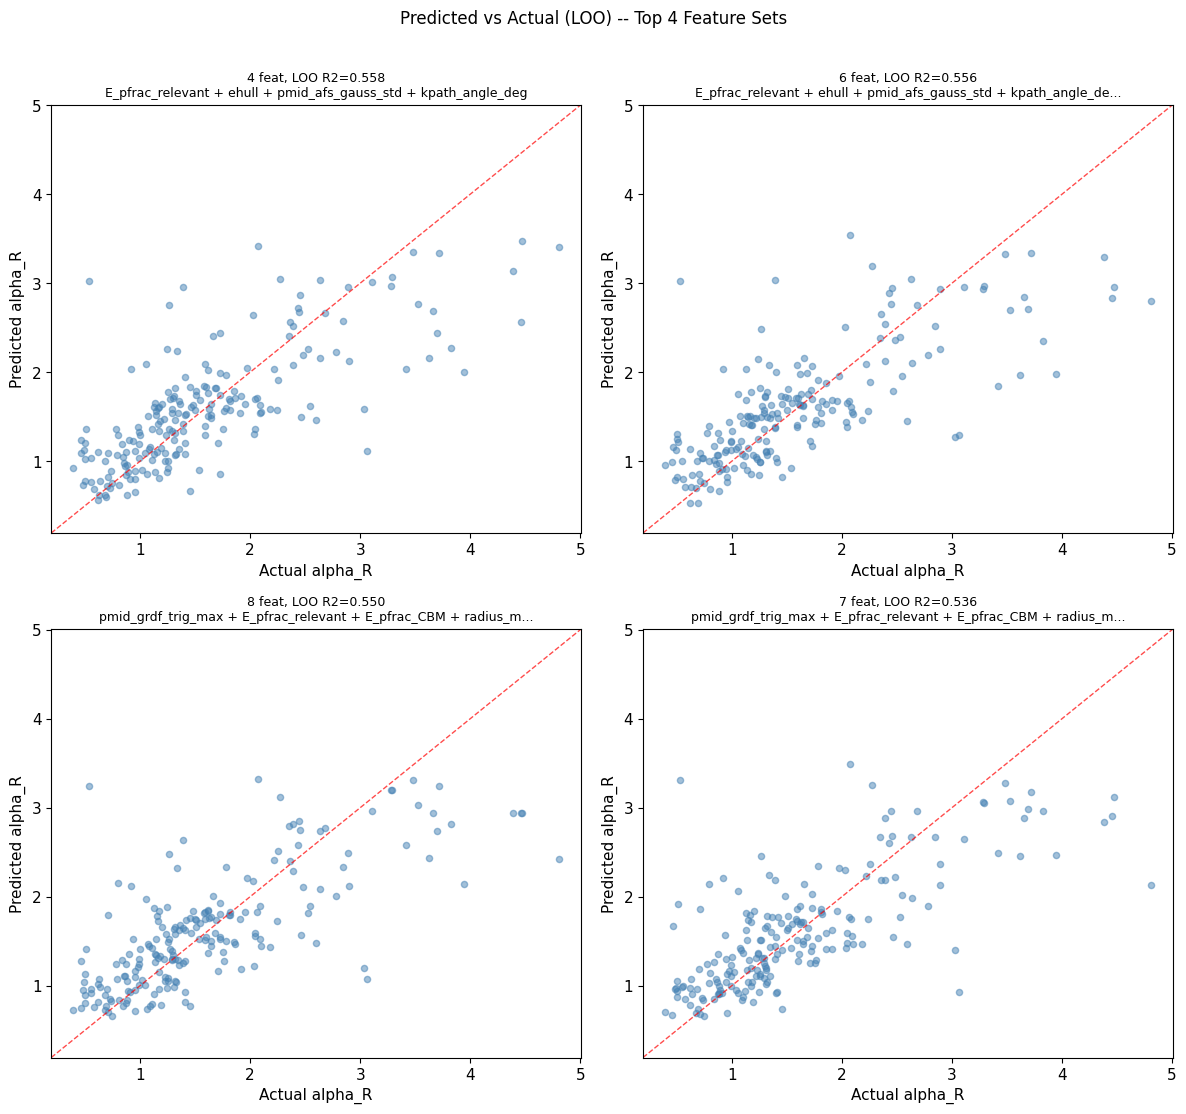

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(12, 11))
axes = axes.flatten()

for idx in range(min(4, len(loo_df))):
    row = loo_df.iloc[idx]
    feats = [f.strip() for f in row['features'].split('+')]
    feat_indices = [np.where(feature_names == f)[0][0] for f in feats]

    X_sub = X_full[:, feat_indices]
    model = XGBRegressor(**XGB_PARAMS)
    y_pred = cross_val_predict(model, X_sub, y, cv=LeaveOneOut())

    ax = axes[idx]
    ax.scatter(y, y_pred, alpha=0.5, s=20, color='steelblue')
    lims = [min(y.min(), y_pred.min()) - 0.2, max(y.max(), y_pred.max()) + 0.2]
    ax.plot(lims, lims, 'r--', lw=1, alpha=0.7)
    ax.set_xlabel('Actual alpha_R')
    ax.set_ylabel('Predicted alpha_R')
    title = f"{row['n_feat']} feat, LOO R2={row['loo_r2']:.3f}"
    # Truncate long feature names
    feat_short = row['features'] if len(row['features']) < 65 else row['features'][:62] + '...'
    ax.set_title(f"{title}\n{feat_short}", fontsize=9)
    ax.set_xlim(lims)
    ax.set_ylim(lims)

plt.suptitle('Predicted vs Actual (LOO) -- Top 4 Feature Sets', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "pred_vs_actual_top4.png"), dpi=150, bbox_inches='tight')
plt.show()

## Cell 13: R2 vs number of features

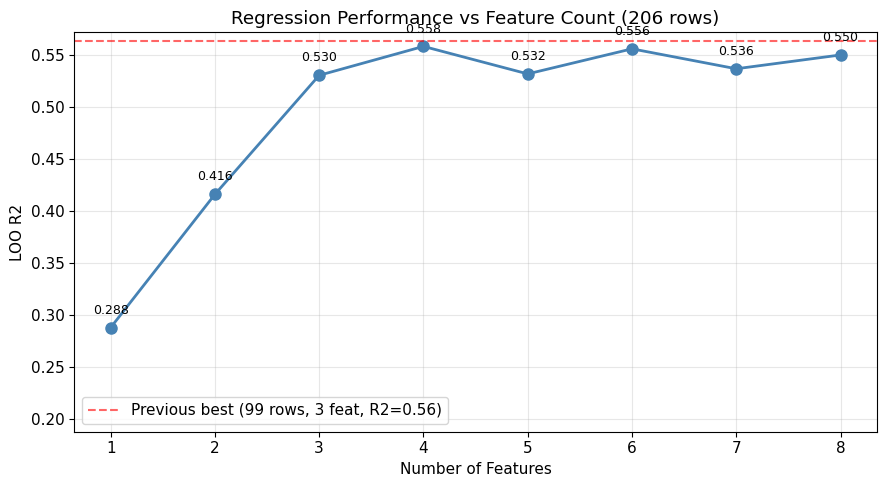

In [29]:
best_by_n = loo_df.loc[loo_df.groupby('n_feat')['loo_r2'].idxmax()]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(best_by_n['n_feat'], best_by_n['loo_r2'], 'o-', color='steelblue', lw=2, markersize=8)
ax.axhline(y=0.563, color='red', linestyle='--', alpha=0.6, label='Previous best (99 rows, 3 feat, R2=0.56)')
ax.set_xlabel('Number of Features')
ax.set_ylabel('LOO R2')
ax.set_title('Regression Performance vs Feature Count (206 rows)')
ax.legend()
ax.set_ylim(bottom=max(-0.1, best_by_n['loo_r2'].min() - 0.1))
ax.set_xticks(range(1, int(best_by_n['n_feat'].max()) + 1))
ax.grid(True, alpha=0.3)

for _, row in best_by_n.iterrows():
    ax.annotate(f"{row['loo_r2']:.3f}", (row['n_feat'], row['loo_r2']),
                textcoords="offset points", xytext=(0, 10), ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "r2_vs_nfeatures.png"), dpi=150, bbox_inches='tight')
plt.show()

## Cell 14: Classification (threshold 1.5 eV*A)

In [30]:
print("=" * 65)
print("  CLASSIFICATION (threshold = 1.5 eV*A)")
print("=" * 65)

THRESHOLD = 1.5
y_class = (y >= THRESHOLD).astype(int)
n_pos = y_class.sum()
n_neg = len(y_class) - n_pos
print(f"Class balance: {n_pos} positive (>= {THRESHOLD}), {n_neg} negative")
print(f"  {n_pos/len(y_class)*100:.1f}% positive\n")

clf_results = []

# Test top 10 regression feature sets for classification
for idx in range(min(10, len(loo_df))):
    row = loo_df.iloc[idx]
    feats = [f.strip() for f in row['features'].split('+')]
    feat_indices = [np.where(feature_names == f)[0][0] for f in feats]
    X_sub = X_full[:, feat_indices]

    # XGBoost classifier with grid search
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', XGBClassifier(
            eval_metric='logloss', use_label_encoder=False,
            random_state=42, verbosity=0
        ))
    ])

    param_grid = {
        'clf__n_estimators': [50, 100, 200],
        'clf__max_depth': [2, 3, 5],
        'clf__learning_rate': [0.05, 0.1, 0.2],
        'clf__scale_pos_weight': [1, 3],
    }

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    grid = GridSearchCV(pipe, param_grid, cv=skf, scoring='f1', n_jobs=-1, refit=True)
    grid.fit(X_sub, y_class)

    # LOO with best model
    best_pipe = grid.best_estimator_
    y_pred_loo = cross_val_predict(best_pipe, X_sub, y_class, cv=LeaveOneOut())
    try:
        y_prob_loo = cross_val_predict(best_pipe, X_sub, y_class, cv=LeaveOneOut(), method='predict_proba')[:, 1]
        auc_val = roc_auc_score(y_class, y_prob_loo)
    except:
        auc_val = np.nan

    result = {
        'n_feat': len(feat_indices),
        'features': ' + '.join(feats),
        'loo_f1': f1_score(y_class, y_pred_loo),
        'loo_auc': auc_val,
        'loo_acc': accuracy_score(y_class, y_pred_loo),
        'loo_prec': precision_score(y_class, y_pred_loo, zero_division=0),
        'loo_rec': recall_score(y_class, y_pred_loo, zero_division=0),
        'reg_loo_r2': row['loo_r2'],
        'best_params': str(grid.best_params_),
    }
    clf_results.append(result)
    print(f"  {len(feat_indices)} feat: F1={result['loo_f1']:.3f}, AUC={result['loo_auc']:.3f}, "
          f"Prec={result['loo_prec']:.3f}, Rec={result['loo_rec']:.3f}")

clf_df = pd.DataFrame(clf_results).sort_values('loo_f1', ascending=False)
clf_df.to_csv(os.path.join(RESULTS_DIR, "classification_results.csv"), index=False)

print(f"\nTop 5 classification results (threshold={THRESHOLD}):")
print(clf_df[['n_feat', 'features', 'loo_f1', 'loo_auc', 'loo_prec', 'loo_rec']].head(5).to_string(index=False))

  CLASSIFICATION (threshold = 1.5 eV*A)
Class balance: 89 positive (>= 1.5), 116 negative
  43.4% positive

  4 feat: F1=0.788, AUC=0.870, Prec=0.702, Rec=0.899
  6 feat: F1=0.816, AUC=0.877, Prec=0.748, Rec=0.899
  8 feat: F1=0.817, AUC=0.928, Prec=0.784, Rec=0.854
  7 feat: F1=0.838, AUC=0.913, Prec=0.761, Rec=0.933
  6 feat: F1=0.784, AUC=0.877, Prec=0.709, Rec=0.876
  5 feat: F1=0.808, AUC=0.877, Prec=0.734, Rec=0.899
  3 feat: F1=0.806, AUC=0.873, Prec=0.738, Rec=0.888
  8 feat: F1=0.804, AUC=0.893, Prec=0.727, Rec=0.899
  7 feat: F1=0.792, AUC=0.894, Prec=0.708, Rec=0.899
  7 feat: F1=0.782, AUC=0.881, Prec=0.699, Rec=0.888

Top 5 classification results (threshold=1.5):
 n_feat                                                                                                                             features   loo_f1  loo_auc  loo_prec  loo_rec
      7         pmid_grdf_trig_max + E_pfrac_relevant + E_pfrac_CBM + radius_mean + pmid_grdf_gauss_std + kstart_frac_x + pmid_afs_trig_m

## Cell 15: Save best feature sets as CSVs

In [31]:
print("=" * 65)
print("  SAVING BEST FEATURE SETS")
print("=" * 65)

for rank in range(min(5, len(loo_df))):
    row = loo_df.iloc[rank]
    feats = [f.strip() for f in row['features'].split('+')]

    save_cols = ID_COLS + feats + [TARGET]
    available = [c for c in save_cols if c in df.columns]
    df_save = df[available]

    fname = f"best_kpath_{rank}_{len(feats)}feat_r2_{row['loo_r2']:.3f}.csv"
    fpath = os.path.join(RESULTS_DIR, fname)
    df_save.to_csv(fpath, index=False)
    print(f"  Saved: {fname}")
    print(f"    Features: {feats}")
    print(f"    LOO R2: {row['loo_r2']:.4f}\n")

  SAVING BEST FEATURE SETS
  Saved: best_kpath_0_4feat_r2_0.558.csv
    Features: ['E_pfrac_relevant', 'ehull', 'pmid_afs_gauss_std', 'kpath_angle_deg']
    LOO R2: 0.5579

  Saved: best_kpath_1_6feat_r2_0.556.csv
    Features: ['E_pfrac_relevant', 'ehull', 'pmid_afs_gauss_std', 'kpath_angle_deg', 'kstart_frac_y', 'band_binary']
    LOO R2: 0.5556

  Saved: best_kpath_2_8feat_r2_0.550.csv
    Features: ['pmid_grdf_trig_max', 'E_pfrac_relevant', 'E_pfrac_CBM', 'radius_mean', 'pmid_grdf_gauss_std', 'kstart_frac_x', 'pmid_afs_trig_mean', 'ehull']
    LOO R2: 0.5497

  Saved: best_kpath_3_7feat_r2_0.536.csv
    Features: ['pmid_grdf_trig_max', 'E_pfrac_relevant', 'E_pfrac_CBM', 'radius_mean', 'pmid_grdf_gauss_std', 'kstart_frac_x', 'pmid_afs_trig_mean']
    LOO R2: 0.5365

  Saved: best_kpath_4_6feat_r2_0.536.csv
    Features: ['E_pfrac_relevant', 'ehull', 'pstart_afs_gauss_std', 'pmid_afs_gauss_std', 'kpath_angle_deg', 'pstart_afs_bessel_std']
    LOO R2: 0.5356



## Cell 16: Summary

In [32]:
print("=" * 65)
print("  NB6 COMPLETE -- SUMMARY")
print("=" * 65)

print(f"\n  Dataset: {X_full.shape[0]} rows, {len(feature_names)} usable features")
print(f"  (from {len(all_feature_cols)} original, removed {len(remove_cols)} constant/NaN)")

print(f"\n  Phase 1 (singles): {len(single_df)} tested")
print(f"    Best: {single_df.iloc[0]['features']} (R2={single_df.iloc[0]['cv5_r2']:.4f})")

print(f"\n  Phase 2 (pairs): {len(pair_df)} tested")
print(f"    Best: {pair_df.iloc[0]['features']} (R2={pair_df.iloc[0]['cv5_r2']:.4f})")

if triple_df is not None:
    print(f"\n  Phase 3 (triples): {len(triple_df)} tested")
    print(f"    Best: {triple_df.iloc[0]['features']} (R2={triple_df.iloc[0]['cv5_r2']:.4f})")

print(f"\n  Phase 4 (forward selection): extended to {int(fwd_df['n_feat'].max())} features")

print(f"\n  Best LOO R2 overall:")
best = loo_df.iloc[0]
print(f"    {best['n_feat']} features: LOO R2 = {best['loo_r2']:.4f}")
print(f"    {best['features']}")

print(f"\n  Previous best (99 rows, 3 feat): LOO R2 = 0.563")
improvement = (best['loo_r2'] - 0.563) / 0.563 * 100
print(f"  Change: {improvement:+.1f}% relative")

if len(clf_df) > 0:
    best_clf = clf_df.iloc[0]
    print(f"\n  Best classification (threshold={THRESHOLD}):")
    print(f"    LOO F1 = {best_clf['loo_f1']:.3f}, AUC = {best_clf['loo_auc']:.3f}")

print(f"\n  All results saved in: {RESULTS_DIR}/")
print(f"""
  Output files:
    phase1_singles.csv           -- all single-feature R2s
    phase2_pairs.csv             -- all pair R2s
    phase3_triples.csv           -- all triple R2s
    phase4_forward_selection.csv -- forward selection traces
    phase5_loo_results.csv       -- LOO R2 for top candidates
    classification_results.csv   -- classification at threshold {THRESHOLD}
    best_kpath_0_*.csv           -- best feature set CSVs
    shap_summary.png / shap_bar.png / feature_importance.png
    pred_vs_actual_top4.png
    r2_vs_nfeatures.png
""")

  NB6 COMPLETE -- SUMMARY

  Dataset: 205 rows, 123 usable features
  (from 130 original, removed 7 constant/NaN)

  Phase 1 (singles): 123 tested
    Best: pmid_grdf_trig_max (R2=0.0806)

  Phase 2 (pairs): 7503 tested
    Best: E_pfrac_relevant + pmid_grdf_trig_max (R2=0.2568)

  Phase 3 (triples): 302621 tested
    Best: E_pfrac_relevant + pmid_grdf_trig_max + pstart_afs_gauss_std (R2=0.4185)

  Phase 4 (forward selection): extended to 8 features

  Best LOO R2 overall:
    4 features: LOO R2 = 0.5579
    E_pfrac_relevant + ehull + pmid_afs_gauss_std + kpath_angle_deg

  Previous best (99 rows, 3 feat): LOO R2 = 0.563
  Change: -0.9% relative

  Best classification (threshold=1.5):
    LOO F1 = 0.838, AUC = 0.913

  All results saved in: .\nb6_feature_selection-results/

  Output files:
    phase1_singles.csv           -- all single-feature R2s
    phase2_pairs.csv             -- all pair R2s
    phase3_triples.csv           -- all triple R2s
    phase4_forward_selection.csv -- forw